In [1]:
import cv2
import numpy
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
import pandas as pd
pd.set_option('display.max_columns',None)

In [3]:
df=pd.read_csv("train_solution_bounding_boxes (1).csv")

In [4]:
df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [5]:
df['image'].duplicated().value_counts()

image
False    355
True     204
Name: count, dtype: int64

In [6]:
grouped=df.groupby('image')[['xmin','ymin','xmax','ymax']].apply(lambda x:x.values.tolist())

In [7]:
unique_images=df['image'].unique()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
train_imgs,val_imgs=train_test_split(unique_images,test_size=0.2)

In [10]:
img_name=grouped.index[0]

In [11]:
img=cv2.cvtColor(cv2.imread(Path('training_images')/img_name),cv2.COLOR_BGR2RGB)

In [12]:
for box in grouped[img_name]:
    xmin,ymin,xmax,ymax=map(int,box)
    cv2.rectangle(img,(xmin,ymin),(xmax,ymax),(255,0,0),2)

In [13]:
img_name

'vid_4_1000.jpg'

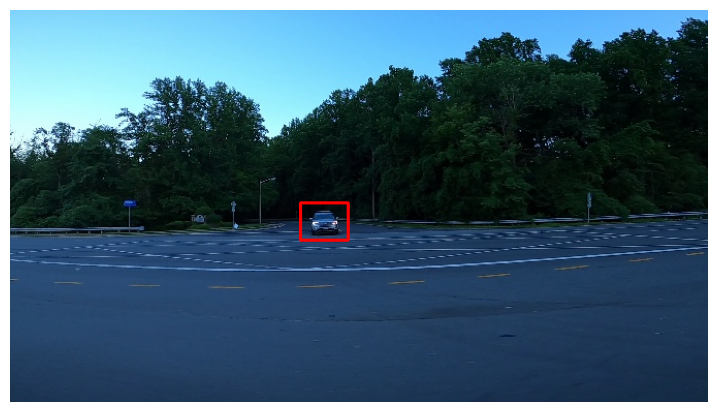

In [14]:
plt.figure(figsize=(9,12))
plt.imshow(img)
plt.axis('off')
plt.show()

In [15]:
img.shape

(380, 676, 3)

In [16]:
import os
def convert_to_yolo(img_w,img_h,boxes,class_id=0):
    yolo_boxes=[]
    for x_min,y_min,x_max,y_max in boxes:
        x_center=(x_min+x_max)/2/img_w
        y_center=(y_min+y_max)/2/img_h
        width=(x_max-x_min)/img_w
        height=(y_max-y_min)/img_h
        yolo_boxes.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
    return yolo_boxes

os.makedirs('labels',exist_ok=True)
for img_name,boxes in grouped.items():
    img=cv2.imread(Path('training_images')/img_name)
    h,w=img.shape[:2]
    yolo_lines=convert_to_yolo(w,h,boxes)

    label_file=img_name.replace('.jpg','.txt')
    with open(f"labels/{label_file}",'w') as f:
        f.write('\n'.join(yolo_lines))

In [17]:
import shutil
for split,img_list in [('train',train_imgs),('val',val_imgs)]:
    os.makedirs(f'dataset/images/{split}',exist_ok=True)
    os.makedirs(f'dataset/labels/{split}',exist_ok=True)
    for img_name in img_list:
        shutil.copy(f'training_images/{img_name}',f'dataset/images/{split}/{img_name}')
        label_name=img_name.replace('.jpg','.txt')
        shutil.copy(f'labels/{label_name}',f'dataset/labels/{split}/{label_name}')

In [18]:
for root,dirs,files in os.walk('dataset'):
    print(f'Folder:{root}|Files:{len(files)}')

Folder:dataset|Files:0
Folder:dataset\images|Files:0
Folder:dataset\images\train|Files:284
Folder:dataset\images\val|Files:71
Folder:dataset\labels|Files:0
Folder:dataset\labels\train|Files:284
Folder:dataset\labels\val|Files:71


In [19]:
import yaml
with open ('data.yaml','w') as f:
    yaml.dump({'path':os.path.abspath('dataset'),'train':'images/train','val':'images/val','nc':1,'names':['car']},
             f,default_flow_style=False,sort_keys=False)